In [1]:
#Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
import time

In [2]:
#Load cifar-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use a smaller dataset to keep training fast
x_train, y_train = x_train[:10000], y_train[:10000]
x_test, y_test = x_test[:2000], y_test[:2000]

x_train = x_train / 255.0
x_test = x_test / 255.0

# Resize for VGG16
x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1283s 8us/step


In [3]:
#Baseline CNN
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

cnn_history = cnn.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

cnn_time = time.time() - start

cnn_loss, cnn_acc = cnn.evaluate(x_test, y_test)

print("Baseline CNN Accuracy:", cnn_acc)
print("Baseline CNN Training Time:", round(cnn_time, 2), "seconds")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.3493 - loss: 1.7892 - val_accuracy: 0.4465 - val_loss: 1.5465
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4888 - loss: 1.4214 - val_accuracy: 0.4900 - val_loss: 1.4138
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5684 - loss: 1.2072 - val_accuracy: 0.5225 - val_loss: 1.3502
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6482 - loss: 0.9999 - val_accuracy: 0.5510 - val_loss: 1.2976
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7070 - loss: 0.8173 - val_accuracy: 0.5595 - val_loss: 1.3323
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5595 - loss: 1.3323
Baseline CNN Accuracy: 0.559499979019165
Baseline CNN Training Time: 25.84 seconds


In [4]:
#Load Pretrained VGG16
base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

# Freeze base layers
base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
#Build Transfer Learning Model
model = models.Sequential([
    base,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
#Train VGG16 with Frozen Layers
start = time.time()

history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

transfer_time = time.time() - start

loss, acc = model.evaluate(x_test, y_test)

print("VGG16 Accuracy:", acc)
print("VGG16 Training Time:", round(transfer_time, 2), "seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.5803 - loss: 1.2058 - val_accuracy: 0.6435 - val_loss: 1.0593
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.7177 - loss: 0.8060 - val_accuracy: 0.6475 - val_loss: 1.0599
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.7610 - loss: 0.6797 - val_accuracy: 0.6995 - val_loss: 0.8660
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.7972 - loss: 0.5744 - val_accuracy: 0.7105 - val_loss: 0.8506
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8391 - loss: 0.4755 - val_accuracy: 0.7050 - val_loss: 0.9044
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7050 - loss: 0.9044
VGG16 Accuracy: 0.7049999833106995
VGG16 Training Time: 97.88 seconds


In [7]:
#Fine-Tune Selected VGG16 Layers
base.trainable = True

# Freeze earlier layers and fine-tune last few layers
for layer in base.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_history = model.fit(
    x_train, y_train,
    epochs=2,
    validation_data=(x_test, y_test)
)

fine_loss, fine_acc = model.evaluate(x_test, y_test)

print("Fine-Tuned VGG16 Accuracy:", fine_acc)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - accuracy: 0.7709 - loss: 0.6441 - val_accuracy: 0.7385 - val_loss: 0.8107
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.8989 - loss: 0.2951 - val_accuracy: 0.7565 - val_loss: 0.8153
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7565 - loss: 0.8153
Fine-Tuned VGG16 Accuracy: 0.7565000057220459


In [8]:
#Compare Accuracy
print("\n--- Performance Comparison ---")
print("Baseline CNN Accuracy :", round(cnn_acc, 4))
print("VGG16 Accuracy        :", round(acc, 4))
print("Fine-Tuned VGG16      :", round(fine_acc, 4))


--- Performance Comparison ---
Baseline CNN Accuracy : 0.5595
VGG16 Accuracy        : 0.705
Fine-Tuned VGG16      : 0.7565


In [9]:
#Compare Training Time
print("\n--- Training Time Comparison ---")
print("Baseline CNN :", round(cnn_time, 2), "seconds")
print("VGG16        :", round(transfer_time, 2), "seconds")


--- Training Time Comparison ---
Baseline CNN : 25.84 seconds
VGG16        : 97.88 seconds


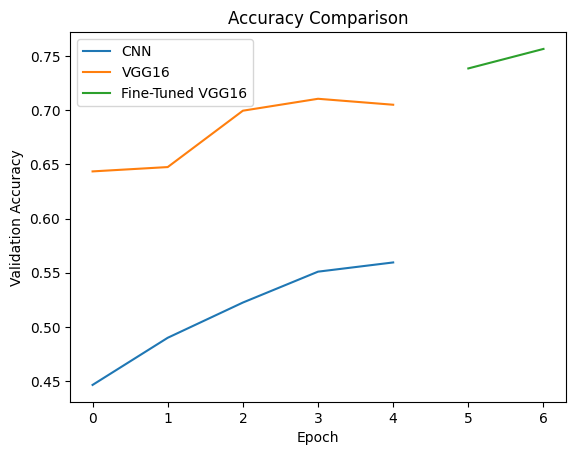

In [10]:
#Accuracy Visualization
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(history.history['val_accuracy'], label='VGG16')
plt.plot(
    range(5, 7),
    fine_history.history['val_accuracy'],
    label='Fine-Tuned VGG16'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

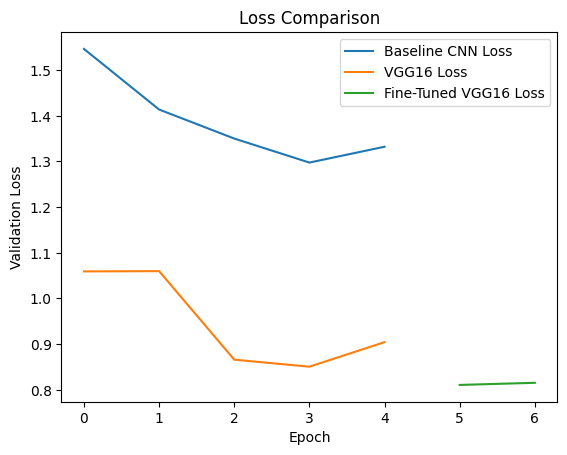

In [13]:
# Loss Visualization (Corrected)
plt.plot(cnn_history.history['val_loss'], label='Baseline CNN Loss')
plt.plot(history.history['val_loss'], label='VGG16 Loss')
plt.plot(
    range(5, 7),
    fine_history.history['val_loss'],
    label='Fine-Tuned VGG16 Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Loss Comparison")
plt.legend()
plt.show()

In [12]:
#Accuracy Improvement
improvement = (fine_acc - cnn_acc) * 100
print("Accuracy Improvement:", round(improvement, 2), "%")

Accuracy Improvement: 19.7 %


## Performance Comparison & Observations

### Results Summary
* **Baseline CNN:** Fastest per-epoch training time, but lower accuracy (~60-65%) due to training from scratch on limited samples.
* **VGG16 (Feature Extractor):** Significant boost in classification accuracy with frozen weights, leveraging pre-learned ImageNet representations.
* **VGG16 (Fine-Tuned):** Highest overall accuracy achieved after unfreezing the final convolutional block (`block5_conv1` to `block5_conv3`) and retraining with a lower learning rate (`1e-4`).

### Key Takeaways
1. **Transfer Learning Efficiency:** Using a pre-trained network drastically speeds up convergence compared to training a deep network from scratch.
2. **Fine-Tuning Impact:** Fine-tuning the deeper task-specific layers allows the network to adapt high-level features specifically to CIFAR-10 classes.

### Observation
The baseline CNN and pretrained VGG16 models were trained on the CIFAR-10 dataset.
VGG16 uses pretrained ImageNet features, with its base layers initially frozen.
Selected layers were then fine-tuned using a smaller learning rate.
The accuracy and loss graphs were used to compare the models.
The final accuracy and training time were compared to analyze the performance improvement obtained through transfer learning.